# Game Product Analytics & A/B Testing

Analyzing player retention, engagement and monetization to evaluate an A/B test and identify actionable product insights.

## Objective

The goal of this analysis is to understand player retention and early engagement, evaluate the impact of two product variants (A and B), and identify which variant performs better across retention and monetization.

## Dataset & Tools

The analysis uses player registration, login activity, and A/B test data to study retention, engagement, and monetization.

**Tools:** Python, Pandas, SciPy, Jupyter Notebook

In [70]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

In [3]:
import os
os.getcwd()

'C:\\Users\\Rhea\\Searches'

## 1. Data Overview

The dataset contains:
- Registration data for 1,000,000 users
- Login/activity records used to measure retention
- A/B test data containing experiment group and revenue

The analysis focuses on three areas: retention, early engagement, and monetization.

In [71]:
print("Registration data:", reg.shape)
print("Activity data:", auth.shape)
print("A/B test data:", ab.shape)

Registration data: (1000000, 3)
Activity data: (9601013, 3)
A/B test data: (404770, 4)


In [5]:
reg=pd.read_csv(r"C:\Users\Rhea\Downloads\Game dataset\reg_data.csv")

In [6]:
reg.head()

,reg_ts;uid
0,911382223;1
1,932683089;2
2,947802447;3
3,959523541;4
4,969103313;5


In [7]:
reg = pd.read_csv(
    r"C:\Users\Rhea\Downloads\Game dataset\reg_data.csv",
    sep=";"
)

In [8]:
reg.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [9]:
reg.info() #checking datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   reg_ts  1000000 non-null  int64
 1   uid     1000000 non-null  int64
dtypes: int64(2)
memory usage: 15.3 MB


## 2. Data Quality Check

Before calculating metrics, the datasets were checked for missing values and duplicate records.

In [72]:
print("Registration missing values:\n", reg.isna().sum())
print("\nActivity missing values:\n", auth.isna().sum())
print("\nA/B test missing values:\n", ab.isna().sum())

Registration missing values:
 reg_ts      0
uid         0
reg_date    0
dtype: int64

Activity missing values:
 auth_ts      0
uid          0
auth_date    0
dtype: int64

A/B test missing values:
 user_id      0
revenue      0
testgroup    0
d1_active    0
dtype: int64


In [73]:
print("Registration duplicates:", reg["uid"].duplicated().sum())
print("Activity duplicates:", auth.duplicated().sum())
print("A/B test duplicates:", ab["user_id"].duplicated().sum())

Registration duplicates: 0
Activity duplicates: 0
A/B test duplicates: 0


In [10]:
pd.to_datetime(reg["reg_ts"], unit="s").head()

0   1998-11-18 09:43:43
1   1999-07-22 22:38:09
2   2000-01-13 22:27:27
3   2000-05-28 14:19:01
4   2000-09-16 11:21:53
Name: reg_ts, dtype: datetime64[ns]

In [11]:
reg["reg_date"] = pd.to_datetime(reg["reg_ts"], unit="s")

In [12]:
reg.head()

,reg_ts,uid,reg_date
0,911382223,1,1998-11-18 09:43:43
1,932683089,2,1999-07-22 22:38:09
2,947802447,3,2000-01-13 22:27:27
3,959523541,4,2000-05-28 14:19:01
4,969103313,5,2000-09-16 11:21:53


In [13]:
auth = pd.read_csv(
    r"C:\Users\Rhea\Downloads\Game dataset\auth_data.csv",
    sep=";"
)

In [14]:
auth.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [15]:
auth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   auth_ts  int64
 1   uid      int64
dtypes: int64(2)
memory usage: 146.5 MB


In [16]:
auth.shape

(9601013, 2)

In [17]:
auth["auth_date"]=pd.to_datetime(auth["auth_ts"],unit="s")

In [18]:
auth.head()

,auth_ts,uid,auth_date
0,911382223,1,1998-11-18 09:43:43
1,932683089,2,1999-07-22 22:38:09
2,932921206,2,1999-07-25 16:46:46
3,933393015,2,1999-07-31 03:50:15
4,933875379,2,1999-08-05 17:49:39


In [19]:
player_activity = auth.merge(
    reg[["uid", "reg_date"]],
    on="uid",
    how="left"
)

In [20]:
player_activity.head()

,auth_ts,uid,auth_date,reg_date
0,911382223,1,1998-11-18 09:43:43,1998-11-18 09:43:43
1,932683089,2,1999-07-22 22:38:09,1999-07-22 22:38:09
2,932921206,2,1999-07-25 16:46:46,1999-07-22 22:38:09
3,933393015,2,1999-07-31 03:50:15,1999-07-22 22:38:09
4,933875379,2,1999-08-05 17:49:39,1999-07-22 22:38:09


In [21]:
player_activity["days_since_registration"] = (
    player_activity["auth_date"] - player_activity["reg_date"]
).dt.days

In [22]:
player_activity.head()

,auth_ts,uid,auth_date,reg_date,days_since_registration
0,911382223,1,1998-11-18 09:43:43,1998-11-18 09:43:43,0
1,932683089,2,1999-07-22 22:38:09,1999-07-22 22:38:09,0
2,932921206,2,1999-07-25 16:46:46,1999-07-22 22:38:09,2
3,933393015,2,1999-07-31 03:50:15,1999-07-22 22:38:09,8
4,933875379,2,1999-08-05 17:49:39,1999-07-22 22:38:09,13


In [23]:
d1 = player_activity[player_activity["days_since_registration"] == 1]["uid"].nunique()
d3 = player_activity[player_activity["days_since_registration"] == 3]["uid"].nunique()
d7 = player_activity[player_activity["days_since_registration"] == 7]["uid"].nunique()
total_players = reg["uid"].nunique()

print("D1:",d1)
print("D3:",d3)
print("D7:",d7)
print("Total:",total_players)

D1: 40202
D3: 49152
D7: 43626
Total: 1000000


In [24]:
player_activity.groupby("days_since_registration")["uid"].nunique().head(15)

days_since_registration
0     1000000
1       40202
2       42991
3       49152
4       56070
5       63713
6       72773
7       43626
8       49667
9       50373
10      51070
11      50599
12      49208
13      46259
14      44513
Name: uid, dtype: int64

In [25]:
player_activity["days_since_registration"].max()

7728

In [26]:
reg["reg_date"].max(), auth["auth_date"].max()

(Timestamp('2020-09-23 15:17:24'), Timestamp('2020-09-23 15:17:24'))

In [27]:
cutoff = auth["auth_date"].max() - pd.Timedelta(days=7)
cutoff

Timestamp('2020-09-16 15:17:24')

In [28]:
eligible_d7 = reg[reg["reg_date"] <= cutoff]
len(eligible_d7)

988555

In [29]:
d7_users = player_activity[
    (player_activity["days_since_registration"] == 7) &
    (player_activity["uid"].isin(eligible_d7["uid"]))
]["uid"].nunique()

d7_rate = d7_users / len(eligible_d7) * 100
print("D7 users:", d7_users)
print("D7 retention:", round(d7_rate, 2), "%")

D7 users: 43626
D7 retention: 4.41 %


In [30]:
cutoff_1 = auth["auth_date"].max() - pd.Timedelta(days=1)
cutoff_3 = auth["auth_date"].max() - pd.Timedelta(days=3)

eligible_d1 = reg[reg["reg_date"] <= cutoff_1]
eligible_d3 = reg[reg["reg_date"] <= cutoff_3]

In [31]:
d1_users = player_activity[(player_activity["days_since_registration"] == 1) & (player_activity["uid"].isin(eligible_d1["uid"]))]["uid"].nunique()
d3_users = player_activity[(player_activity["days_since_registration"] == 3) & (player_activity["uid"].isin(eligible_d3["uid"]))]["uid"].nunique()

print("D1:", round(d1_users / len(eligible_d1) * 100, 2), "%")
print("D3:", round(d3_users / len(eligible_d3) * 100, 2), "%")

D1: 4.03 %
D3: 4.94 %


In [32]:
early = player_activity[player_activity["days_since_registration"].between(0, 6)]
engagement = early.groupby("uid")["days_since_registration"].nunique()
engagement.head()

uid
1    1
2    2
3    1
4    1
5    1
Name: days_since_registration, dtype: int64

In [33]:
engagement.value_counts().sort_index()

days_since_registration
1    761623
2    162283
3     66157
4      9453
5       475
6         9
Name: count, dtype: int64

In [34]:
d7_users = set(player_activity[player_activity["days_since_registration"] == 7]["uid"])
engagement_df = engagement.reset_index()
engagement_df.columns = ["uid", "active_days"]
engagement_df["d7_retained"] = engagement_df["uid"].isin(d7_users)

In [35]:
engagement_df.groupby("active_days")["d7_retained"].mean().round(4) * 100

active_days
1     0.00
2    20.46
3    14.14
4    10.94
5     7.16
6     0.00
Name: d7_retained, dtype: float64

In [36]:
pd.crosstab(engagement_df["active_days"], engagement_df["d7_retained"])

d7_retained,False,True
active_days,,
1,761622,1
2,129079,33204
3,56804,9353
4,8419,1034
5,441,34
6,9,0


In [37]:
d3_users = set(player_activity[player_activity["days_since_registration"] == 3]["uid"])
engagement_df["d3_retained"] = engagement_df["uid"].isin(d3_users)

In [38]:
engagement_df.groupby("active_days")["d3_retained"].mean().round(4) * 100

active_days
1     0.00
2    15.07
3    30.31
4    45.82
5    62.74
6    66.67
Name: d3_retained, dtype: float64

In [39]:
early.groupby(["uid", "days_since_registration"]).size().reset_index().head(20)

,uid,days_since_registration,0
0,1,0,1
1,2,0,1
2,2,2,1
3,3,0,1
4,4,0,1
5,5,0,1
6,6,0,1
7,7,0,1
8,8,0,1
9,9,0,1


In [40]:
early_3 = player_activity[player_activity["days_since_registration"].between(0, 2)]
engagement_3 = early_3.groupby("uid")["days_since_registration"].nunique()

In [41]:
engagement_3.value_counts().sort_index()

days_since_registration
1    919843
2     77121
3      3036
Name: count, dtype: int64

In [42]:
engagement_3_df = engagement_3.reset_index()
engagement_3_df.columns = ["uid", "active_days"]

d3_users = set(player_activity[player_activity["days_since_registration"] == 3]["uid"])
engagement_3_df["d3_retained"] = engagement_3_df["uid"].isin(d3_users)

engagement_3_df.groupby("active_days")["d3_retained"].mean().round(4) * 100

active_days
1     4.32
2    11.99
3     5.70
Name: d3_retained, dtype: float64

In [43]:
d1_users = set(player_activity[player_activity["days_since_registration"] == 1]["uid"])
d2_users = set(player_activity[player_activity["days_since_registration"] == 2]["uid"])

engagement_3_df["d1_active"] = engagement_3_df["uid"].isin(d1_users)
engagement_3_df["d2_active"] = engagement_3_df["uid"].isin(d2_users)

In [44]:
print("D3 retention if active on D1:", round(engagement_3_df.groupby("d1_active")["d3_retained"].mean()[True] * 100, 2), "%")
print("D3 retention if active on D2:", round(engagement_3_df.groupby("d2_active")["d3_retained"].mean()[True] * 100, 2), "%")

D3 retention if active on D1: 15.7 %
D3 retention if active on D2: 7.63 %


In [45]:
print("D1 active:", engagement_3_df["d1_active"].sum())
print("D2 active:", engagement_3_df["d2_active"].sum())

D1 active: 40202
D2 active: 42991


In [46]:
ab = pd.read_csv(
    r"C:\Users\Rhea\Downloads\Game dataset\ab_test.csv",
    sep=";"
)

In [47]:
ab.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [48]:
ab["testgroup"].value_counts()

testgroup
b    202667
a    202103
Name: count, dtype: int64

In [49]:
ab.groupby("testgroup")["revenue"].agg(["count", "sum", "mean"])

,count,sum,mean
testgroup,,,
a,202103,5136189,25.413720
b,202667,5421603,26.751287


In [50]:
ab.groupby("testgroup")["revenue"].describe()

,count,mean,std,min,25%,50%,75%,max
testgroup,,,,,,,,
a,202103.0,25.413720,920.768137,0.0,0.0,0.0,0.0,37433.0
b,202667.0,26.751287,287.324162,0.0,0.0,0.0,0.0,4000.0


In [51]:
ab.groupby("testgroup")["revenue"].apply(lambda x: (x > 0).mean() * 100)

testgroup
a    0.953969
b    0.890624
Name: revenue, dtype: float64

In [52]:
ab[ab["revenue"] > 0].groupby("testgroup")["revenue"].agg(["count", "mean", "median"])

,count,mean,median
testgroup,,,
a,1928,2663.998444,311.0
b,1805,3003.658172,3022.0


In [53]:
from scipy.stats import mannwhitneyu

a_rev = ab[ab["testgroup"] == "a"]["revenue"]
b_rev = ab[ab["testgroup"] == "b"]["revenue"]

stat, p = mannwhitneyu(a_rev, b_rev, alternative="two-sided")

print("p-value:", p)

p-value: 0.06269701316074398


In [54]:
from scipy.stats import chi2_contingency

table = pd.crosstab(ab["testgroup"], ab["revenue"] > 0)
chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 0.03647561892312613


In [55]:
a_rev = ab[ab["testgroup"] == "a"]["revenue"].sum()
b_rev = ab[ab["testgroup"] == "b"]["revenue"].sum()

print("Revenue difference:", b_rev - a_rev)
print("B vs A:", round((b_rev / a_rev - 1) * 100, 2), "%")

Revenue difference: 285414
B vs A: 5.56 %


In [56]:
player_activity = player_activity.merge(
    ab[["user_id", "testgroup"]],
    left_on="uid",
    right_on="user_id",
    how="left"
)

In [57]:
player_activity.head()

,auth_ts,uid,auth_date,reg_date,days_since_registration,user_id,testgroup
0,911382223,1,1998-11-18 09:43:43,1998-11-18 09:43:43,0,1.0,b
1,932683089,2,1999-07-22 22:38:09,1999-07-22 22:38:09,0,2.0,a
2,932921206,2,1999-07-25 16:46:46,1999-07-22 22:38:09,2,2.0,a
3,933393015,2,1999-07-31 03:50:15,1999-07-22 22:38:09,8,2.0,a
4,933875379,2,1999-08-05 17:49:39,1999-07-22 22:38:09,13,2.0,a


In [58]:
d1 = player_activity[player_activity["days_since_registration"] == 1]
d1.groupby("testgroup")["uid"].nunique()

testgroup
a    7306
b    7310
Name: uid, dtype: int64

In [59]:
d1.groupby("testgroup")["uid"].nunique() / ab.groupby("testgroup")["user_id"].nunique() * 100

testgroup
a    3.614988
b    3.606902
dtype: float64

In [60]:
d3 = player_activity[player_activity["days_since_registration"] == 3]
d3.groupby("testgroup")["uid"].nunique() / ab.groupby("testgroup")["user_id"].nunique() * 100

testgroup
a    4.465050
b    4.505914
dtype: float64

In [61]:
d7 = player_activity[player_activity["days_since_registration"] == 7]
d7.groupby("testgroup")["uid"].nunique() / ab.groupby("testgroup")["user_id"].nunique() * 100

testgroup
a    3.925226
b    4.025816
dtype: float64

In [62]:
from scipy.stats import chi2_contingency

d7_table = pd.crosstab(
    ab["testgroup"],
    ab["user_id"].isin(d7["uid"])
)

chi2, p, dof, expected = chi2_contingency(d7_table)

print("D7 p-value:", p)

D7 p-value: 0.10317405324207017


In [64]:
player_activity.groupby(["testgroup", "days_since_registration"])["uid"].nunique().head(20)

testgroup  days_since_registration
a          0                          181982
           1                            7306
           2                            7922
           3                            9024
           4                           10360
           5                           11754
           6                           13369
           7                            7933
           8                            9180
           9                            9397
           10                           9504
           11                           9498
           12                           9021
           13                           8715
           14                           8357
           15                           8390
           16                           8147
           17                           7998
           18                           7524
           19                           7502
Name: uid, dtype: int64

In [65]:
player_activity.groupby(["testgroup", "days_since_registration"])["uid"].nunique().unstack(0).head(8)

testgroup,a,b
days_since_registration,,
0,181982.0,182573.0
1,7306.0,7310.0
2,7922.0,7951.0
3,9024.0,9132.0
4,10360.0,10193.0
5,11754.0,11709.0
6,13369.0,13483.0
7,7933.0,8159.0


In [66]:
d1_users = set(player_activity[player_activity["days_since_registration"] == 1]["uid"])

ab["d1_active"] = ab["user_id"].isin(d1_users)

ab.groupby("d1_active")["revenue"].apply(lambda x: (x > 0).mean() * 100)

d1_active
False    0.922713
True     0.909962
Name: revenue, dtype: float64

In [67]:
ab[ab["revenue"] > 0].groupby("testgroup")["revenue"].agg(
    ["count", "mean", "median", "sum"]
)

,count,mean,median,sum
testgroup,,,,
a,1928,2663.998444,311.0,5136189
b,1805,3003.658172,3022.0,5421603


In [68]:
from statsmodels.stats.proportion import proportions_ztest

counts = [1928, 1805]
nobs = [202103, 202667]

z, p = proportions_ztest(counts, nobs)
print("z:", z)
print("p-value:", p)

z: 2.108028495889841
p-value: 0.035028524642854865


## 3. Retention Analysis

Retention measures how consistently users return to the game after registration.

D1, D3, and D7 retention are used to understand short-term and early long-term engagement.

In [74]:
retention = player_activity.groupby("days_since_registration")["uid"].nunique()
retention.head(8)

days_since_registration
0    1000000
1      40202
2      42991
3      49152
4      56070
5      63713
6      72773
7      43626
Name: uid, dtype: int64

In [75]:
for day in [1, 3, 7]:
    print(f"D{day} retention:", round(retention[day] / retention[0] * 100, 2), "%")

D1 retention: 4.02 %
D3 retention: 4.92 %
D7 retention: 4.36 %


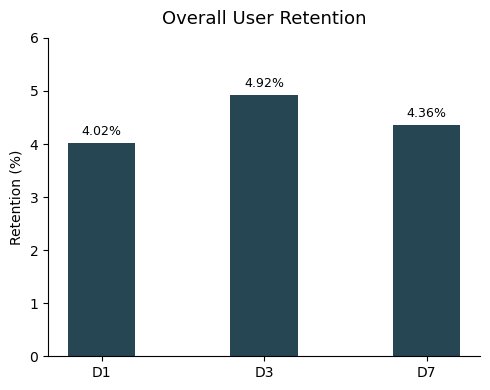

In [102]:
retention_pct = {
    "D1": retention[1] / retention[0] * 100,
    "D3": retention[3] / retention[0] * 100,
    "D7": retention[7] / retention[0] * 100
}

fig, ax = plt.subplots(figsize=(5, 4))

x = [0, 0.6, 1.2]
values = list(retention_pct.values())

bars = ax.bar(x, values, width=0.25, color="#264653")

ax.set_xticks(x)
ax.set_xticklabels(["D1", "D3", "D7"])
ax.set_title("Overall User Retention", fontsize=13, pad=10)
ax.set_ylabel("Retention (%)")
ax.set_ylim(0, 6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.15,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Retention Insight

Overall retention was 4.02% on D1, 4.92% on D3, and 4.36% on D7. The relatively low return rates suggest that retaining users beyond their initial session is an important product opportunity.

## 4. Early Engagement

To understand user engagement beyond simple retention, we look at how many different days each player was active during the first 7 days after registration.

In [77]:
early_activity = player_activity[
    player_activity["days_since_registration"] <= 7
].groupby("uid")["days_since_registration"].nunique()

early_activity.value_counts().sort_index()

days_since_registration
1    761622
2    129080
3     90008
4     17772
5      1475
6        43
Name: count, dtype: int64

In [78]:
engagement_pct = early_activity.value_counts(normalize=True).sort_index() * 100
engagement_pct.round(2)

days_since_registration
1    76.16
2    12.91
3     9.00
4     1.78
5     0.15
6     0.00
Name: proportion, dtype: float64

### Engagement Insight

Most users were active on only one day during their first week, while only a small proportion returned consistently. This suggests that increasing repeat engagement during the first week could be an important retention opportunity.

In [84]:
early_activity = player_activity[
    player_activity["days_since_registration"] <= 6
].groupby("uid")["days_since_registration"].nunique()


In [85]:
d7_users = set(
    player_activity[player_activity["days_since_registration"] == 7]["uid"]
)

early_activity_df = early_activity.reset_index()
early_activity_df["d7_retained"] = early_activity_df["uid"].isin(d7_users)

In [86]:
early_retention = early_activity_df.groupby(
    "days_since_registration"
)["d7_retained"].mean() * 100

early_retention.round(2)

days_since_registration
1     0.00
2    20.46
3    14.14
4    10.94
5     7.16
6     0.00
Name: d7_retained, dtype: float64

In [81]:
print(len(d7_users))
print(early_activity_df["d7_retained"].value_counts())

43626
d7_retained
False    956374
True      43626
Name: count, dtype: int64


In [82]:
pd.crosstab(early_activity_df["days_since_registration"], early_activity_df["d7_retained"])

d7_retained,False,True
days_since_registration,,
1,761622,0
2,129079,1
3,56804,33204
4,8419,9353
5,441,1034
6,9,34


## 5. A/B Test Analysis

The A/B test compares two product variants, A and B, across user retention and monetization.

The main questions are:
- Does either variant improve retention?
- Does either variant improve payer conversion?
- Does either variant generate higher revenue?

In [87]:
ab.groupby("testgroup")["user_id"].nunique()

testgroup
a    202103
b    202667
Name: user_id, dtype: int64

In [88]:
payer_rate = ab.groupby("testgroup")["revenue"].apply(
    lambda x: (x > 0).mean() * 100
)
payer_rate.round(3)

testgroup
a    0.954
b    0.891
Name: revenue, dtype: float64

In [89]:
counts = [
    (ab.loc[ab["testgroup"] == "a", "revenue"] > 0).sum(),
    (ab.loc[ab["testgroup"] == "b", "revenue"] > 0).sum()
]
nobs = [
    (ab["testgroup"] == "a").sum(),
    (ab["testgroup"] == "b").sum()
]

z, p = proportions_ztest(counts, nobs)
print("p-value:", p)

p-value: 0.035028524642854865


### Payer Conversion Insight

Variant A had a higher payer conversion rate than Variant B (0.954% vs 0.891%). The difference was statistically significant (p = 0.035), suggesting that Variant A was more effective at converting users into paying customers.

In [90]:
revenue_summary = ab.groupby("testgroup")["revenue"].agg(["sum", "mean"])
revenue_summary.round(2)

,sum,mean
testgroup,,
a,5136189,25.41
b,5421603,26.75


In [91]:
a_rev = ab[ab["testgroup"] == "a"]["revenue"]
b_rev = ab[ab["testgroup"] == "b"]["revenue"]

stat, p = mannwhitneyu(a_rev, b_rev, alternative="two-sided")
print("p-value:", p)

p-value: 0.06269701316074398


### Revenue Insight

Variant B generated higher observed revenue than Variant A (5.42M vs 5.14M), representing a 5.56% increase. However, the difference was not statistically significant (p = 0.063), so there is not enough evidence to conclude that Variant B improves revenue.

### Retention by Variant

Retention was compared across D1, D3, and D7 to determine whether either variant improved user engagement over time.

In [93]:
for day in [1, 3, 7]:
    d = player_activity[player_activity["days_since_registration"] == day]
    rates = d.groupby("testgroup")["uid"].nunique() / ab.groupby("testgroup")["user_id"].nunique() * 100
    print(f"D{day}:", rates.round(2).to_dict())

D1: {'a': 3.61, 'b': 3.61}
D3: {'a': 4.47, 'b': 4.51}
D7: {'a': 3.93, 'b': 4.03}


In [94]:
d7 = player_activity[player_activity["days_since_registration"] == 7]

d7_table = pd.crosstab(
    ab["testgroup"],
    ab["user_id"].isin(d7["uid"])
)

chi2, p, dof, expected = chi2_contingency(d7_table)
print("D7 p-value:", p)

D7 p-value: 0.10317405324207017


### Retention Insight

Variant B showed slightly higher observed D3 and D7 retention, but the differences were small and the D7 difference was not statistically significant (p = 0.103). Therefore, neither variant can be considered superior for retention based on this experiment.

## 6. Key Findings

### Retention
- D1 retention: **4.02%**
- D3 retention: **4.92%**
- D7 retention: **4.36%**
- **76.16% of users were active on only one day during their first week**, indicating limited repeat engagement.

### A/B Test
- The experiment groups were well balanced: approximately **202K users each**.
- Variant A had higher payer conversion: **0.954% vs 0.891%**.
- The payer conversion difference was statistically significant (**p = 0.035**).
- Variant B generated **5.56% higher observed revenue**, but the difference was not statistically significant (**p = 0.063**).
- B showed slightly higher observed D3 and D7 retention, but the D7 difference was not statistically significant (**p = 0.103**).

## 7. Product Recommendation

Based on the analysis, Variant A is the safer choice for the current rollout because it produced a statistically significant improvement in payer conversion.

Variant B showed promising monetization signals, including 5.56% higher observed revenue and higher revenue among paying users, but the overall revenue difference was not statistically significant.

A practical next step would be to retain Variant A while running a follow-up experiment focused on understanding the monetization behaviour observed in Variant B.

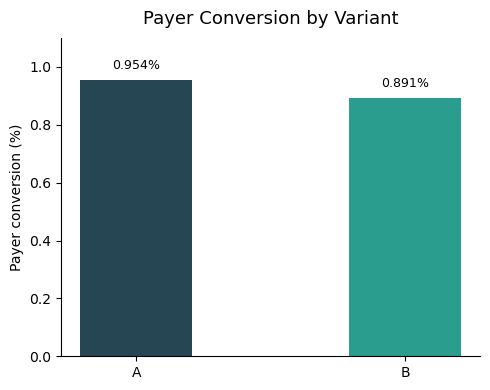

In [100]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))

x = [0, 0.6]
values = payer_rate.values
bars = ax.bar(x, values, width=0.25, color=["#264653", "#2A9D8F"])

ax.set_xticks(x)
ax.set_xticklabels(["A", "B"])
ax.set_title("Payer Conversion by Variant", fontsize=13, pad=10)
ax.set_ylabel("Payer conversion (%)")
ax.set_ylim(0, 1.1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.04,
        f"{value:.3f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

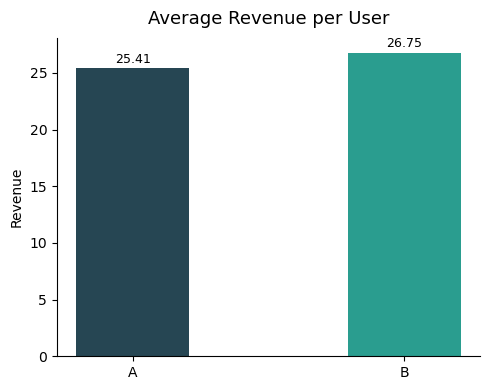

In [99]:
fig, ax = plt.subplots(figsize=(5, 4))

x = [0, 0.6]
values = revenue_summary["mean"].values

bars = ax.bar(x, values, width=0.25, color=["#264653", "#2A9D8F"])

ax.set_xticks(x)
ax.set_xticklabels(["A", "B"])
ax.set_title("Average Revenue per User", fontsize=13, pad=10)
ax.set_ylabel("Revenue")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

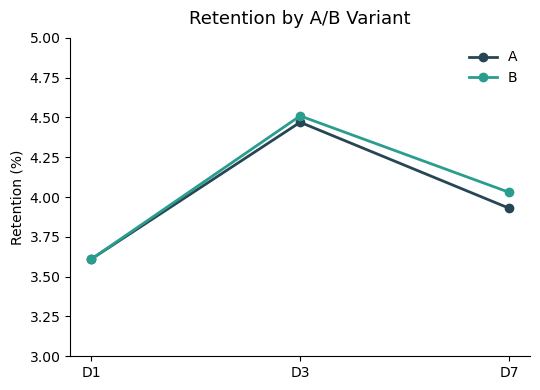

In [104]:
retention_ab = pd.DataFrame({
    "A": [3.61, 4.47, 3.93],
    "B": [3.61, 4.51, 4.03]
}, index=["D1", "D3", "D7"])

fig, ax = plt.subplots(figsize=(5.5, 4))

x = range(3)

ax.plot(x, retention_ab["A"], marker="o", linewidth=2,
        color="#264653", label="A")
ax.plot(x, retention_ab["B"], marker="o", linewidth=2,
        color="#2A9D8F", label="B")

ax.set_xticks(x)
ax.set_xticklabels(retention_ab.index)
ax.set_title("Retention by A/B Variant", fontsize=13, pad=10)
ax.set_ylabel("Retention (%)")
ax.set_ylim(3, 5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 8. Conclusion

The analysis shows that early user retention is relatively low, with most users failing to return consistently during their first week.

In the A/B test, Variant A achieved significantly higher payer conversion, while Variant B showed higher observed revenue but without statistically significant evidence of improvement. Retention differences between the variants were also not statistically significant.

Overall, Variant A is the safer choice for rollout, while the monetization behaviour observed in Variant B could be investigated through a follow-up experiment.